# 07 — Modelo com Conceitos de Alarme

## Objetivo

Testar uma primeira representação auditável de `conceito_alarme` contra o baseline com
`Id_Alarme`, mantendo congelados:

- limpeza analítica;
- expurgo localizado da `PE3798`;
- deduplicação exata;
- sequência com gap de 60 segundos;
- janelas de observação/horizonte de 8 horas;
- lacuna global de `31/05/2025`;
- split temporal;
- escolha de threshold apenas na validação.

## Regra contra vazamento

O conceito usado neste notebook é uma normalização textual determinística do campo `Alarme`. A
seleção de quais conceitos viram colunas do modelo é feita por frequência apenas no treino. O teste
não participa da seleção de features, parâmetros ou threshold.

Este notebook não cria uma taxonomia técnica final. Ele testa se a aproximação por conceito textual
ajuda antes de investir em um mapa manual `Id_Alarme -> conceito_alarme -> familia_alarme`.

In [1]:
from pathlib import Path
import re
import time
import unicodedata

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score, fbeta_score,
    precision_score, recall_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 200)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

SEQUENCE_GAP_SECONDS = 60
OBSERVATION_HOURS = 8
HORIZON_HOURS = 8
TOP_ALARM_IDS = 200
TOP_CONCEPTS = 200
MISSING_DAY = pd.Timestamp("2025-05-31")
LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

def normalize_alarm_name(value):
    if pd.isna(value):
        return "SEM_DESCRICAO"
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s*\(L-?\d+\)\s*$", "", text)
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or "SEM_DESCRICAO"

def is_excavator(series):
    return series.fillna("").str.contains("ESCAV", case=False, regex=True)

print(f"Raiz do projeto: {ROOT}")
print("Modelo com conceitos textuais, mantendo o baseline congelado.")

Raiz do projeto: /home/f_szekut/projects/vale_correct
Modelo com conceitos textuais, mantendo o baseline congelado.


## 1. Reconstituição da base auditada

Esta etapa repete a preparação dos notebooks 03, 04, 05 e 06. A repetição é intencional para manter o
notebook independente e auditável.

In [2]:
start = time.time()

con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE alarm_sequences AS
    WITH ordered AS (
        SELECT *,
               lag(Data_Evento) OVER (
                   PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
               ) AS evento_anterior
        FROM analytic_events
    ), flagged AS (
        SELECT *,
               CASE
                   WHEN evento_anterior IS NULL THEN 1
                   WHEN date_diff('millisecond', evento_anterior, Data_Evento)
                        > {SEQUENCE_GAP_SECONDS * 1000} THEN 1
                   ELSE 0
               END AS nova_sequencia
        FROM ordered
    ), numbered AS (
        SELECT *,
               sum(nova_sequencia) OVER (
                   PARTITION BY TAG, Id_Alarme
                   ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
               ) AS numero_sequencia
        FROM flagged
    )
    SELECT
        TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
        Id_Alarme, any_value(Alarme) AS Alarme,
        numero_sequencia,
        min(Data_Evento) AS inicio,
        max(Data_Evento) AS fim,
        date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo) AS registros_brutos_representados,
        max(Is_Dont_Go) AS is_dont_go,
        max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
        max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
        max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
        max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
    FROM numbered
    GROUP BY TAG, Id_Alarme, numero_sequencia
    '''
)

base_audit = query(
    '''
    SELECT
        (SELECT count(*) FROM analytic_events) AS registros_analiticos,
        (SELECT sum(ids_evento_no_grupo - 1) FROM analytic_events) AS duplicatas_retiradas,
        (SELECT sum(Is_Dont_Go) FROM analytic_events) AS linhas_dont_go,
        (SELECT count(*) FROM alarm_sequences) AS sequencias,
        (SELECT sum(is_dont_go) FROM alarm_sequences) AS sequencias_dont_go
    '''
)
base_audit["tempo_s"] = round(time.time() - start, 1)
display(base_audit)

,registros_analiticos,duplicatas_retiradas,linhas_dont_go,sequencias,sequencias_dont_go,tempo_s
0,35608094,265564.0,19941.0,4303625,14612.0,94.7


## 2. Conceitos textuais e janelas

O campo `conceito_alarme_textual` é derivado apenas do texto do alarme. Exemplos:

- `OEM Interface normal` e `Oem Interface Normal` viram o mesmo conceito;
- sufixos como `(L-1850)` são removidos;
- acentos e pontuação são normalizados.

Essa normalização ainda não entende componente, posição, severidade ou regra operacional. Ela é só o
primeiro teste de redução de fragmentação textual.

In [3]:
alarm_catalog = query(
    '''
    SELECT Id_Alarme, any_value(Alarme) AS Alarme, count(*) AS sequencias
    FROM alarm_sequences
    GROUP BY 1
    ORDER BY sequencias DESC
    '''
)
alarm_catalog["conceito_alarme_textual"] = alarm_catalog["Alarme"].map(normalize_alarm_name)
display(alarm_catalog.head(20))

concept_audit = (
    alarm_catalog.groupby("conceito_alarme_textual")
    .agg(
        ids=("Id_Alarme", "nunique"),
        sequencias=("sequencias", "sum"),
        id_alarmes=("Id_Alarme", lambda x: ", ".join(map(str, sorted(set(x))))),
        descricoes=("Alarme", lambda x: " | ".join(sorted(set(map(str, x)))[:5])),
    )
    .reset_index()
    .sort_values(["ids", "sequencias"], ascending=[False, False])
)
display(concept_audit.head(30))

con.register("alarm_concepts", alarm_catalog[["Id_Alarme", "conceito_alarme_textual"]])

con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE sequence_bins AS
    SELECT
        TAG,
        time_bucket(INTERVAL '8 hours', inicio) AS bin_start,
        count(*) AS sequencias_total,
        count(DISTINCT Id_Alarme) AS alarmes_distintos,
        sum(registros_analiticos) AS registros_analiticos,
        sum(registros_brutos_representados) AS registros_brutos_representados,
        avg(duracao_ms) AS duracao_media_ms,
        max(duracao_ms) AS duracao_max_ms,
        max(registros_analiticos) AS maior_sequencia_registros,
        sum(possui_critico) AS sequencias_com_critico,
        sum(possui_activate) AS sequencias_com_activate,
        sum(possui_inactive) AS sequencias_com_inactive,
        sum(possui_classe_nula) AS sequencias_com_classe_nula,
        sum(is_dont_go) AS episodios_dont_go
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)

con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE sample_grid AS
    WITH tags AS (
        SELECT DISTINCT TAG FROM analytic_events
    ), feature_bins AS (
        SELECT * FROM generate_series(
            TIMESTAMP '2025-01-01 00:00:00',
            TIMESTAMP '2025-06-30 08:00:00',
            INTERVAL '8 hours'
        ) AS t(feature_start)
    )
    SELECT
        tags.TAG,
        feature_start,
        feature_start + INTERVAL '8 hours' AS prediction_time,
        feature_start + INTERVAL '16 hours' AS target_end
    FROM tags CROSS JOIN feature_bins
    '''
)

samples = query(
    f'''
    SELECT
        g.TAG, g.feature_start, g.prediction_time, g.target_end,
        coalesce(f.sequencias_total, 0) AS sequencias_total,
        coalesce(f.alarmes_distintos, 0) AS alarmes_distintos,
        coalesce(f.registros_analiticos, 0) AS registros_analiticos,
        coalesce(f.registros_brutos_representados, 0) AS registros_brutos_representados,
        coalesce(f.duracao_media_ms, 0) AS duracao_media_ms,
        coalesce(f.duracao_max_ms, 0) AS duracao_max_ms,
        coalesce(f.maior_sequencia_registros, 0) AS maior_sequencia_registros,
        coalesce(f.sequencias_com_critico, 0) AS sequencias_com_critico,
        coalesce(f.sequencias_com_activate, 0) AS sequencias_com_activate,
        coalesce(f.sequencias_com_inactive, 0) AS sequencias_com_inactive,
        coalesce(f.sequencias_com_classe_nula, 0) AS sequencias_com_classe_nula,
        coalesce(y.episodios_dont_go, 0) AS episodios_dont_go_target,
        CASE WHEN coalesce(y.episodios_dont_go, 0) > 0 THEN 1 ELSE 0 END AS target,
        CASE
            WHEN CAST(g.feature_start AS DATE) = DATE '{MISSING_DAY.date()}'
              OR CAST(g.prediction_time AS DATE) = DATE '{MISSING_DAY.date()}'
            THEN 0 ELSE 1
        END AS amostra_valida
    FROM sample_grid g
    LEFT JOIN sequence_bins f
      ON g.TAG = f.TAG AND g.feature_start = f.bin_start
    LEFT JOIN sequence_bins y
      ON g.TAG = y.TAG AND g.prediction_time = y.bin_start
    ORDER BY g.prediction_time, g.TAG
    '''
)
samples = samples[samples["amostra_valida"] == 1].copy()

tag_profile = query(
    '''
    SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
    FROM analytic_events
    GROUP BY 1
    '''
)
samples = samples.merge(tag_profile, how="left", on="TAG")
samples["eh_escavadeira"] = is_excavator(samples["Tipo"]).astype("int8")
samples["eh_caminhao"] = (samples["Tipo"].fillna("") == "Caminhao").astype("int8")

samples = samples.assign(split=np.select(
    [
        samples["prediction_time"] < pd.Timestamp("2025-05-01"),
        samples["prediction_time"] < pd.Timestamp("2025-05-31"),
        samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
    ],
    ["treino", "validacao", "teste"],
    default="fora_do_split",
))
samples = samples[samples["split"].isin(["treino", "validacao", "teste"])].copy()

display(
    samples.groupby(["split", "Tipo"])
    .agg(amostras=("target", "size"), positivas=("target", "sum"), prevalencia=("target", "mean"))
    .reset_index()
)

,Id_Alarme,Alarme,sequencias,conceito_alarme_textual
0,335609934,Rx Channel A Not Receiving Messages,298922,RX CHANNEL A NOT RECEIVING MESSAGES
1,335609935,Rx Channel B Not Receiving Messages,298750,RX CHANNEL B NOT RECEIVING MESSAGES
2,1074008262,Rollback Stick Limited By End Of Travel,175119,ROLLBACK STICK LIMITED BY END OF TRAVEL
3,1074008247,Lift Arms Too High,165135,LIFT ARMS TOO HIGH
4,1074008259,Lower Hoist Limited By End Of Travel,158657,LOWER HOIST LIMITED BY END OF TRAVEL
5,1074008258,Left Steer Limited By End Of Travel,152455,LEFT STEER LIMITED BY END OF TRAVEL
6,1074008261,Right Steer Limited By End Of Travel,133827,RIGHT STEER LIMITED BY END OF TRAVEL
7,1074008257,Dump Wheel Limited By End Of Travel,132340,DUMP WHEEL LIMITED BY END OF TRAVEL
8,1074008264,Bucket Load Weight,132106,BUCKET LOAD WEIGHT
9,335609927,6th Tire Tag Timeout,124704,6TH TIRE TAG TIMEOUT


,conceito_alarme_textual,ids,sequencias,id_alarmes,descricoes
387,MC QUEDA PRESSAO DO OLEO MOTOR 280KPA,50,3552,"16833846, 16833859, 16833860, 16833906, 168339...",MC - QUEDA PRESSÃO DO ÓLEO MOTOR <280KPA
535,TESTE OP ENTRADA OPERACAO ARTICULADA,41,41,"16833669, 16833670, 16833671, 16833672, 168336...",TESTE-OP ENTRADA OPERAÇÃO ARTICULADA.
379,MC BAIXA PRESSAO DO OLEO MOTOR 240KPA,31,121,"16833452, 16833453, 16833462, 16833470, 168334...",MC - BAIXA PRESSÃO DO ÓLEO MOTOR <240KPA
429,OP BAIXO NIVEL DE COMBUSTIVEL 20,30,1808,"16832236, 16832237, 16832612, 16832613, 168326...",OP - BAIXO NÍVEL DE COMBUSTÍVEL <20%
361,MA BAIXA VOLTAGEM COM EQUIP DESLIGADO 24V,28,13967,"16833325, 16833326, 16833327, 16833328, 168333...",MA - BAIXA VOLTAGEM COM EQUIP. DESLIGADO <24V
377,MC BAIXA PRESSAO DE AR DE FREIO 90PSI,28,4690,"16831533, 16831534, 16831535, 16831536, 168315...",MC - Baixa Pressão de Ar de Freio <90psi
363,MA DIF TEMP EXAUST 60 C,27,10789,"16833543, 16833544, 16833545, 16833546, 168335...",MA - Dif Temp Exaust > 60 ºC
533,TCS FALHA SENSOR DE ROTACAO DA RODA TRAS ESQ,27,6935,"16830654, 16830655, 16830656, 16830657, 168306...",TCS-Falha Sensor de Rotação da Roda TRAS ESQ
431,OP FREIO RETARDO AUTO DESLIGADO,27,1130,"16831702, 16831703, 16831705, 16831707, 168317...",OP - FREIO RETARDO AUTO DESLIGADO
532,TCS FALHA SENSOR DE ROTACAO DA RODA TRAS DIR,26,1343,"16830615, 16830616, 16830617, 16830618, 168306...",TCS-Falha Sensor de Rotação da Roda TRAS DIR


,split,Tipo,amostras,positivas,prevalencia
0,teste,Caminhao,2670,288,0.107865
1,teste,Escavadeira,445,2,0.004494
2,treino,Caminhao,10770,1906,0.176973
3,treino,Escavadeira,1795,16,0.008914
4,validacao,Caminhao,2700,281,0.104074
5,validacao,Escavadeira,450,7,0.015556


## 3. Features de `Id_Alarme` e conceito

Os 200 `Id_Alarme` e 200 conceitos mais frequentes são escolhidos somente no treino. O objetivo é
comparar representações com a mesma disciplina temporal.

In [4]:
top_alarm_ids = query(
    f'''
    SELECT Id_Alarme, count(*) AS sequencias
    FROM alarm_sequences
    WHERE inicio < TIMESTAMP '2025-05-01 00:00:00'
    GROUP BY 1
    ORDER BY sequencias DESC, Id_Alarme
    LIMIT {TOP_ALARM_IDS}
    '''
)
alarm_ids = top_alarm_ids["Id_Alarme"].astype(int).tolist()
alarm_columns = ",\n".join(
    f"sum(CASE WHEN Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
    for alarm_id in alarm_ids
)
alarm_bin_features = query(
    f'''
    SELECT TAG, time_bucket(INTERVAL '8 hours', inicio) AS feature_start,
           {alarm_columns}
    FROM alarm_sequences
    GROUP BY 1, 2
    '''
)
samples = samples.merge(alarm_bin_features, how="left", on=["TAG", "feature_start"])
alarm_feature_names = [f"alarm_{alarm_id}" for alarm_id in alarm_ids]
samples[alarm_feature_names] = samples[alarm_feature_names].fillna(0).astype("int32")

top_concepts = query(
    f'''
    SELECT c.conceito_alarme_textual, count(*) AS sequencias
    FROM alarm_sequences s
    JOIN alarm_concepts c USING (Id_Alarme)
    WHERE s.inicio < TIMESTAMP '2025-05-01 00:00:00'
    GROUP BY 1
    ORDER BY sequencias DESC, conceito_alarme_textual
    LIMIT {TOP_CONCEPTS}
    '''
)
concepts = top_concepts["conceito_alarme_textual"].tolist()
concept_name_map = {concept: f"concept_{i:03d}" for i, concept in enumerate(concepts)}

concept_long = query(
    '''
    SELECT
        s.TAG,
        time_bucket(INTERVAL '8 hours', s.inicio) AS feature_start,
        c.conceito_alarme_textual,
        count(*) AS sequencias
    FROM alarm_sequences s
    JOIN alarm_concepts c USING (Id_Alarme)
    GROUP BY 1, 2, 3
    '''
)
concept_long = concept_long[concept_long["conceito_alarme_textual"].isin(concepts)].copy()
concept_wide = (
    concept_long.pivot_table(
        index=["TAG", "feature_start"],
        columns="conceito_alarme_textual",
        values="sequencias",
        aggfunc="sum",
        fill_value=0,
    )
    .rename(columns=concept_name_map)
    .reset_index()
)
concept_wide.columns.name = None
concept_feature_names = [concept_name_map[c] for c in concepts]
samples = samples.merge(concept_wide, how="left", on=["TAG", "feature_start"])
samples[concept_feature_names] = samples[concept_feature_names].fillna(0).astype("int32")

samples = pd.concat([
    samples,
    pd.DataFrame({
        "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
        "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
        "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
        "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
        "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
    }, index=samples.index)
], axis=1).copy()

base_feature_columns = [
    "sequencias_total", "alarmes_distintos", "registros_analiticos",
    "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
    "maior_sequencia_registros", "sequencias_com_critico",
    "sequencias_com_activate", "sequencias_com_inactive",
    "sequencias_com_classe_nula", "feature_has_events",
    "prediction_hour_sin", "prediction_hour_cos",
    "prediction_dow_sin", "prediction_dow_cos",
]
type_feature_columns = ["eh_escavadeira", "eh_caminhao"]

display(top_alarm_ids.head(15))
display(top_concepts.head(30))

,Id_Alarme,sequencias
0,335609934,182752
1,335609935,182624
2,1074008262,111374
3,1074008247,105921
4,1074008259,101078
5,1074008258,96490
6,1074008261,85451
7,1074008264,84072
8,335609927,81822
9,1074008257,80897


,conceito_alarme_textual,sequencias
0,RX CHANNEL A NOT RECEIVING MESSAGES,182752
1,RX CHANNEL B NOT RECEIVING MESSAGES,182624
2,ROLLBACK STICK LIMITED BY END OF TRAVEL,111374
3,LIFT ARMS TOO HIGH,105921
4,LOWER HOIST LIMITED BY END OF TRAVEL,101078
5,LEFT STEER LIMITED BY END OF TRAVEL,96490
6,RIGHT STEER LIMITED BY END OF TRAVEL,85451
7,BUCKET LOAD WEIGHT,84072
8,6TH TIRE TAG TIMEOUT,81822
9,DUMP WHEEL LIMITED BY END OF TRAVEL,80897


## 4. Modelos comparados

Comparações:

1. `RF_ids`: baseline equivalente ao notebook 03;
2. `RF_conceitos`: troca IDs por conceitos textuais;
3. `RF_ids_conceitos`: usa IDs e conceitos juntos;
4. `RF_conceitos_tipo`: conceitos mais flags de tipo;
5. `RF_ids_conceitos_tipo`: IDs, conceitos e flags de tipo.

As flags de tipo testam uma separação leve entre caminhões e escavadeiras sem ainda treinar modelos
separados.

In [5]:
def get_split(df, name, columns):
    part = df[df["split"] == name].copy()
    return part[columns].astype("float32"), part["target"].astype("int8"), part

def select_threshold(y_true, probability):
    scores = pd.DataFrame([
        {
            "threshold": threshold,
            "f2": fbeta_score(y_true, probability >= threshold, beta=2, zero_division=0),
            "precision": precision_score(y_true, probability >= threshold, zero_division=0),
            "recall": recall_score(y_true, probability >= threshold, zero_division=0),
        }
        for threshold in np.linspace(0.01, 0.99, 197)
    ])
    best = scores.sort_values(
        ["f2", "precision", "threshold"], ascending=[False, False, False]
    ).iloc[0]["threshold"]
    return float(best), scores

def metric_row(model_name, split, y_true, probability, threshold):
    prediction = (probability >= threshold).astype(int)
    return {
        "modelo": model_name,
        "split": split,
        "threshold": threshold,
        "amostras": len(y_true),
        "positivas": int(y_true.sum()),
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "f2": fbeta_score(y_true, prediction, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "predicoes_positivas": int(prediction.sum()),
    }

def fit_rf(model_name, columns):
    X_train, y_train, train_meta = get_split(samples, "treino", columns)
    X_val, y_val, val_meta = get_split(samples, "validacao", columns)
    X_test, y_test, test_meta = get_split(samples, "teste", columns)

    model = RandomForestClassifier(
        n_estimators=400,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    val_prob = model.predict_proba(X_val)[:, 1]
    threshold, threshold_scores = select_threshold(y_val, val_prob)
    test_prob = model.predict_proba(X_test)[:, 1]

    rows = [
        metric_row(model_name, "validacao", y_val, val_prob, threshold),
        metric_row(model_name, "teste", y_test, test_prob, threshold),
    ]

    pred = test_meta[["TAG", "Tipo", "Tag_Frota", "feature_start", "prediction_time", "target"]].copy()
    pred["probabilidade"] = test_prob
    pred["predito"] = (test_prob >= threshold).astype("int8")
    pred["modelo"] = model_name
    pred["erro"] = np.select(
        [
            (pred["target"] == 1) & (pred["predito"] == 1),
            (pred["target"] == 0) & (pred["predito"] == 1),
            (pred["target"] == 1) & (pred["predito"] == 0),
            (pred["target"] == 0) & (pred["predito"] == 0),
        ],
        ["TP", "FP", "FN", "TN"],
        default="indefinido",
    )
    return pd.DataFrame(rows), pred, model

feature_sets = {
    "RF_ids": base_feature_columns + alarm_feature_names,
    "RF_conceitos": base_feature_columns + concept_feature_names,
    "RF_ids_conceitos": base_feature_columns + alarm_feature_names + concept_feature_names,
    "RF_conceitos_tipo": base_feature_columns + concept_feature_names + type_feature_columns,
    "RF_ids_conceitos_tipo": base_feature_columns + alarm_feature_names + concept_feature_names + type_feature_columns,
}

all_metrics = []
all_predictions = []
models = {}

for model_name, columns in feature_sets.items():
    print(f"Treinando {model_name} com {len(columns)} features...")
    metrics_part, pred_part, model = fit_rf(model_name, columns)
    all_metrics.append(metrics_part)
    all_predictions.append(pred_part)
    models[model_name] = model

metrics = pd.concat(all_metrics, ignore_index=True)
predictions = pd.concat(all_predictions, ignore_index=True)

display(metrics.sort_values(["split", "f2"], ascending=[True, False]))

Treinando RF_ids com 216 features...


Treinando RF_conceitos com 216 features...


Treinando RF_ids_conceitos com 416 features...


Treinando RF_conceitos_tipo com 218 features...


Treinando RF_ids_conceitos_tipo com 418 features...


,modelo,split,threshold,amostras,positivas,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas
5,RF_ids_conceitos,teste,0.160,3115,290,0.346223,0.817072,0.205433,0.834483,0.329700,0.517536,0.751578,1178
3,RF_conceitos,teste,0.170,3115,290,0.336839,0.813915,0.199497,0.820690,0.320971,0.505737,0.741318,1193
9,RF_ids_conceitos_tipo,teste,0.185,3115,290,0.343625,0.810776,0.221074,0.737931,0.340223,0.502820,0.735514,968
7,RF_conceitos_tipo,teste,0.155,3115,290,0.335430,0.813380,0.185629,0.855172,0.305043,0.496795,0.735020,1336
1,RF_ids,teste,0.205,3115,290,0.330037,0.807777,0.210019,0.751724,0.328313,0.495905,0.730729,1038
8,RF_ids_conceitos_tipo,validacao,0.185,3150,288,0.335416,0.786114,0.205466,0.704861,0.318182,0.474299,0.715289,988
4,RF_ids_conceitos,validacao,0.160,3150,288,0.332187,0.787917,0.188356,0.763889,0.302198,0.474138,0.716326,1168
2,RF_conceitos,validacao,0.170,3150,288,0.334938,0.788059,0.187179,0.760417,0.300412,0.471576,0.714066,1170
6,RF_conceitos_tipo,validacao,0.155,3150,288,0.332991,0.787731,0.174298,0.819444,0.287454,0.470870,0.714404,1354
0,RF_ids,validacao,0.205,3150,288,0.335803,0.788176,0.203685,0.690972,0.314625,0.467356,0.709567,977


## 5. Comparação no teste

A leitura principal é contra `RF_ids`, o baseline com IDs. Conceitos só justificam próximo investimento
se melhorarem teste ou se reduzirem erros importantes sem degradar demais o resultado agregado.

,modelo,amostras,positivas,threshold,pr_auc,precision,recall,f2,predicoes_positivas
5,RF_ids_conceitos,3115,290,0.160,0.346223,0.205433,0.834483,0.517536,1178
3,RF_conceitos,3115,290,0.170,0.336839,0.199497,0.820690,0.505737,1193
9,RF_ids_conceitos_tipo,3115,290,0.185,0.343625,0.221074,0.737931,0.502820,968
7,RF_conceitos_tipo,3115,290,0.155,0.335430,0.185629,0.855172,0.496795,1336
1,RF_ids,3115,290,0.205,0.330037,0.210019,0.751724,0.495905,1038


,modelo,TP,FP,FN,TN,precision,recall,f2
3,RF_ids_conceitos,242,936,48,1889,0.205433,0.834483,0.517536
0,RF_conceitos,238,955,52,1870,0.199497,0.820690,0.505737
4,RF_ids_conceitos_tipo,214,754,76,2071,0.221074,0.737931,0.502820
1,RF_conceitos_tipo,248,1088,42,1737,0.185629,0.855172,0.496795
2,RF_ids,218,820,72,2005,0.210019,0.751724,0.495905


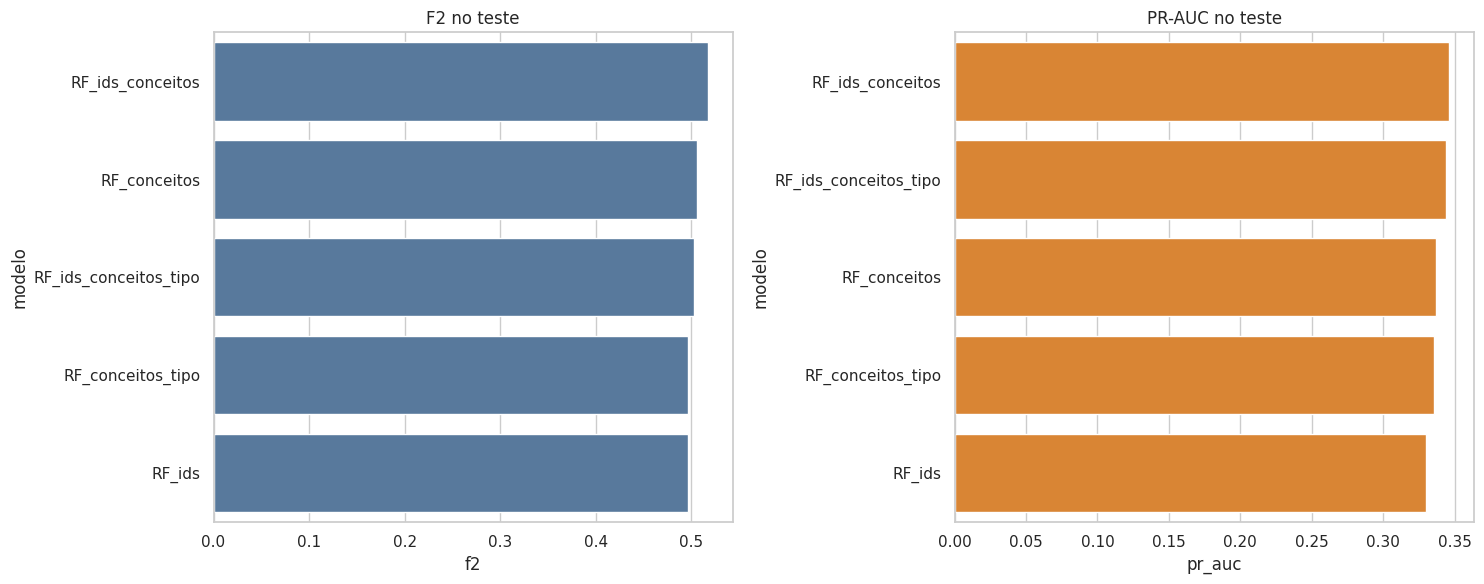

In [6]:
test_metrics = metrics[metrics["split"] == "teste"].copy()
display(
    test_metrics[
        ["modelo", "amostras", "positivas", "threshold", "pr_auc", "precision", "recall", "f2", "predicoes_positivas"]
    ].sort_values("f2", ascending=False)
)

cm_summary = (
    predictions.assign(
        TP=lambda d: (d["erro"] == "TP").astype(int),
        FP=lambda d: (d["erro"] == "FP").astype(int),
        FN=lambda d: (d["erro"] == "FN").astype(int),
        TN=lambda d: (d["erro"] == "TN").astype(int),
    )
    .groupby("modelo")
    .agg(TP=("TP", "sum"), FP=("FP", "sum"), FN=("FN", "sum"), TN=("TN", "sum"))
    .reset_index()
)
display(cm_summary.merge(test_metrics[["modelo", "precision", "recall", "f2"]], on="modelo").sort_values("f2", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=test_metrics.sort_values("f2", ascending=False), x="f2", y="modelo", ax=axes[0], color="#4C78A8")
axes[0].set(title="F2 no teste")
sns.barplot(data=test_metrics.sort_values("pr_auc", ascending=False), x="pr_auc", y="modelo", ax=axes[1], color="#F58518")
axes[1].set(title="PR-AUC no teste")
plt.tight_layout()
plt.show()

## 6. Segmentação por tipo

Esta seção verifica se conceitos ou flags de tipo melhoram o recorte de escavadeiras. Com o target
atual, qualquer conclusão sobre escavadeiras precisa ser fraca: há apenas 2 positivos no teste.

In [7]:
type_rows = []
for (model_name, tipo), part in predictions.groupby(["modelo", "Tipo"], dropna=False):
    prediction = part["predito"].to_numpy()
    y_true = part["target"].to_numpy()
    type_rows.append({
        "modelo": model_name,
        "Tipo": tipo,
        "amostras": len(part),
        "positivas": int(y_true.sum()),
        "predicoes_positivas": int(prediction.sum()),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f2": fbeta_score(y_true, prediction, beta=2, zero_division=0),
        "FP": int(((y_true == 0) & (prediction == 1)).sum()),
        "FN": int(((y_true == 1) & (prediction == 0)).sum()),
        "prob_media": part["probabilidade"].mean(),
        "prob_p90": part["probabilidade"].quantile(.90),
    })

type_metrics = pd.DataFrame(type_rows)
display(type_metrics.sort_values(["Tipo", "f2"], ascending=[True, False]))

excavator_rows = type_metrics[type_metrics["Tipo"].fillna("").str.contains("Escavadeira", case=False, regex=False)]
display(excavator_rows.sort_values("prob_media", ascending=False))

,modelo,Tipo,amostras,positivas,predicoes_positivas,precision,recall,f2,FP,FN,prob_media,prob_p90
6,RF_ids_conceitos,Caminhao,2670,288,1177,0.205607,0.840278,0.519536,935,46,0.194646,0.381195
0,RF_conceitos,Caminhao,2670,288,1192,0.199664,0.826389,0.507679,954,50,0.199256,0.387675
8,RF_ids_conceitos_tipo,Caminhao,2670,288,968,0.221074,0.743056,0.504717,754,74,0.195929,0.383805
2,RF_conceitos_tipo,Caminhao,2670,288,1335,0.185768,0.861111,0.498593,1087,40,0.202314,0.391825
4,RF_ids,Caminhao,2670,288,1038,0.210019,0.756944,0.497717,820,70,0.206883,0.389586
1,RF_conceitos,Escavadeira,445,2,1,0.000000,0.000000,0.000000,1,2,0.023213,0.059569
3,RF_conceitos_tipo,Escavadeira,445,2,1,0.000000,0.000000,0.000000,1,2,0.018172,0.039879
5,RF_ids,Escavadeira,445,2,0,0.000000,0.000000,0.000000,0,2,0.024088,0.071657
7,RF_ids_conceitos,Escavadeira,445,2,1,0.000000,0.000000,0.000000,1,2,0.021932,0.058529
9,RF_ids_conceitos_tipo,Escavadeira,445,2,0,0.000000,0.000000,0.000000,0,2,0.017217,0.038589


,modelo,Tipo,amostras,positivas,predicoes_positivas,precision,recall,f2,FP,FN,prob_media,prob_p90
5,RF_ids,Escavadeira,445,2,0,0.0,0.0,0.0,0,2,0.024088,0.071657
1,RF_conceitos,Escavadeira,445,2,1,0.0,0.0,0.0,1,2,0.023213,0.059569
7,RF_ids_conceitos,Escavadeira,445,2,1,0.0,0.0,0.0,1,2,0.021932,0.058529
3,RF_conceitos_tipo,Escavadeira,445,2,1,0.0,0.0,0.0,1,2,0.018172,0.039879
9,RF_ids_conceitos_tipo,Escavadeira,445,2,0,0.0,0.0,0.0,0,2,0.017217,0.038589


## 7. Importâncias dos conceitos

Se conceitos forem competitivos, os conceitos mais importantes orientam o mapa manual futuro. A
importância do Random Forest não é causal; ela é apenas uma triagem para inspeção.

In [8]:
concept_lookup = pd.DataFrame({
    "feature": [concept_name_map[c] for c in concepts],
    "conceito_alarme_textual": concepts,
})

importance_rows = []
for model_name in ["RF_conceitos", "RF_conceitos_tipo", "RF_ids_conceitos_tipo"]:
    columns = feature_sets[model_name]
    importances = pd.DataFrame({
        "feature": columns,
        "importance": models[model_name].feature_importances_,
        "modelo": model_name,
    })
    importance_rows.append(importances)

importances = pd.concat(importance_rows, ignore_index=True)
concept_importances = (
    importances.merge(concept_lookup, how="inner", on="feature")
    .sort_values(["modelo", "importance"], ascending=[True, False])
)
display(concept_importances.groupby("modelo").head(30))

,feature,importance,modelo,conceito_alarme_textual
36,concept_036,0.051911,RF_conceitos,ENGINE COOLANT LEVEL ACTIVE
37,concept_037,0.050384,RF_conceitos,ENGINE COOLANT LEVEL INACTIVE
11,concept_011,0.028556,RF_conceitos,DIPPER
17,concept_017,0.028298,RF_conceitos,LOAD
15,concept_015,0.023592,RF_conceitos,BODY UP
16,concept_016,0.022222,RF_conceitos,CYCLE
25,concept_025,0.020362,RF_conceitos,OEM INTERFACE NORMAL
23,concept_023,0.019551,RF_conceitos,OEM INTERFACE TIMEOUT
35,concept_035,0.013469,RF_conceitos,PAYLOAD OVERLOAD INACTIVE
34,concept_034,0.012082,RF_conceitos,PAYLOAD OVERLOAD ACTIVE


## 8. Leitura auditada

Critérios de decisão:

- se conceitos textuais superarem IDs, avançar para um mapa manual pequeno;
- se conceitos só empatarem, ainda podem ser úteis para reduzir dimensionalidade e explicar erros;
- se conceitos piorarem muito, continuar usando IDs e criar conceitos apenas para análise;
- se flags de tipo não melhorarem escavadeiras, não separar modelos ainda;
- se escavadeiras continuarem sem recall, priorizar target melhor ou custo real antes de modelo
  pesado específico.